In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from dysts.systems import get_attractor_list
from dysts.flows import __dict__ as flow_models
from dysts.analysis import gp_dim
from dysts.metrics import estimate_kl_divergence
import os

In [2]:
granularity = 30
noise1 = 0
noise = 1e-3
forecast_length = 300
D = 10
#D = granularity//2

equation_names = get_attractor_list()
equation_names.remove('FluidTrampoline')
equation_names.remove('HyperLu')
equation_names.remove('SprottMore')
equation_names.remove('StickSlipOscillator')
#equation_names = equation_names[:2]

In [3]:
Parrot_average_vpt = np.load(f'./parrot_statistics/CL=512/granularity={granularity}_noise={noise1}_D={D}_average_vpt.npy',allow_pickle='TRUE').item()
Parrot_median_vpt = np.load(f'./parrot_statistics/CL=512/granularity={granularity}_noise={noise1}_D={D}_median_vpt.npy',allow_pickle='TRUE').item()
Parrot_average_smape = np.load(f'./parrot_statistics/CL=512/granularity={granularity}_noise={noise1}_D={D}_average_smape.npy',allow_pickle='TRUE').item()
Parrot_median_smape = np.load(f'./parrot_statistics/CL=512/granularity={granularity}_noise={noise1}_D={D}_median_smape.npy',allow_pickle='TRUE').item()
Parrot_average_cdim = np.load(f'./parrot_statistics/CL=512/granularity={granularity}_noise={noise1}_D={D}_average_cdim.npy',allow_pickle='TRUE').item()
Parrot_median_cdim = np.load(f'./parrot_statistics/CL=512/granularity={granularity}_noise={noise1}_D={D}_median_cdim.npy',allow_pickle='TRUE').item()
Parrot_average_kl = np.load(f'./parrot_statistics/CL=512/granularity={granularity}_noise={noise1}_D={D}_average_kl.npy',allow_pickle='TRUE').item()
Parrot_median_kl = np.load(f'./parrot_statistics/CL=512/granularity={granularity}_noise={noise1}_D={D}_median_kl.npy',allow_pickle='TRUE').item()
Parrot_average_vpt_2 = np.load(f'./parrot_statistics/CL=512/granularity={granularity}_noise={noise1}_D={D}_average_vpt_2.npy',allow_pickle='TRUE').item()
Parrot_median_vpt_2 = np.load(f'./parrot_statistics/CL=512/granularity={granularity}_noise={noise1}_D={D}_median_vpt_2.npy',allow_pickle='TRUE').item()
Parrot_average_smape_2 = np.load(f'./parrot_statistics/CL=512/granularity={granularity}_noise={noise1}_D={D}_average_smape_2.npy',allow_pickle='TRUE').item()
Parrot_median_smape_2 = np.load(f'./parrot_statistics/CL=512/granularity={granularity}_noise={noise1}_D={D}_median_smape_2.npy',allow_pickle='TRUE').item()
Parrot_average_mse = np.load(f'./parrot_statistics/CL=512/granularity={granularity}_noise={noise1}_D={D}_average_mse.npy',allow_pickle='TRUE').item()
Parrot_median_mse = np.load(f'./parrot_statistics/CL=512/granularity={granularity}_noise={noise1}_D={D}_median_mse.npy',allow_pickle='TRUE').item()
Parrot_average_mae = np.load(f'./parrot_statistics/CL=512/granularity={granularity}_noise={noise1}_D={D}_average_mae.npy',allow_pickle='TRUE').item()
Parrot_median_mae = np.load(f'./parrot_statistics/CL=512/granularity={granularity}_noise={noise1}_D={D}_median_mae.npy',allow_pickle='TRUE').item()

In [4]:
TimesFM_average_vpt = np.load(f'./TimesFM_statistics/CL=512/granularity={granularity}_noise={noise}_average_vpt.npy',allow_pickle='TRUE').item()
TimesFM_median_vpt = np.load(f'./TimesFM_statistics/CL=512/granularity={granularity}_noise={noise}_median_vpt.npy',allow_pickle='TRUE').item()
TimesFM_average_smape = np.load(f'./TimesFM_statistics/CL=512/granularity={granularity}_noise={noise}_average_smape.npy',allow_pickle='TRUE').item()
TimesFM_median_smape = np.load(f'./TimesFM_statistics/CL=512/granularity={granularity}_noise={noise}_median_smape.npy',allow_pickle='TRUE').item()
TimesFM_average_cdim = np.load(f'./TimesFM_statistics/CL=512/granularity={granularity}_noise={noise}_average_cdim.npy',allow_pickle='TRUE').item()
TimesFM_median_cdim = np.load(f'./TimesFM_statistics/CL=512/granularity={granularity}_noise={noise}_median_cdim.npy',allow_pickle='TRUE').item()
TimesFM_average_kl = np.load(f'./TimesFM_statistics/CL=512/granularity={granularity}_noise={noise}_average_kl.npy',allow_pickle='TRUE').item()
TimesFM_median_kl = np.load(f'./TimesFM_statistics/CL=512/granularity={granularity}_noise={noise}_median_kl.npy',allow_pickle='TRUE').item()
TimesFM_average_vpt_2 = np.load(f'./TimesFM_statistics/CL=512/granularity={granularity}_noise={noise}_average_vpt_2.npy',allow_pickle='TRUE').item()
TimesFM_median_vpt_2 = np.load(f'./TimesFM_statistics/CL=512/granularity={granularity}_noise={noise}_median_vpt_2.npy',allow_pickle='TRUE').item()
TimesFM_average_smape_2 = np.load(f'./TimesFM_statistics/CL=512/granularity={granularity}_noise={noise}_average_smape_2.npy',allow_pickle='TRUE').item()
TimesFM_median_smape_2 = np.load(f'./TimesFM_statistics/CL=512/granularity={granularity}_noise={noise}_median_smape_2.npy',allow_pickle='TRUE').item()
TimesFM_average_mse = np.load(f'./TimesFM_statistics/CL=512/granularity={granularity}_noise={noise}_average_mse.npy',allow_pickle='TRUE').item()
TimesFM_median_mse = np.load(f'./TimesFM_statistics/CL=512/granularity={granularity}_noise={noise}_median_mse.npy',allow_pickle='TRUE').item()
TimesFM_average_mae = np.load(f'./TimesFM_statistics/CL=512/granularity={granularity}_noise={noise}_average_mae.npy',allow_pickle='TRUE').item()
TimesFM_median_mae = np.load(f'./TimesFM_statistics/CL=512/granularity={granularity}_noise={noise}_median_mae.npy',allow_pickle='TRUE').item()

In [5]:
TimeMoE_average_vpt = np.load(f'./TimeMoE_statistics/CL=512/granularity={granularity}_noise={noise}_average_vpt.npy',allow_pickle='TRUE').item()
TimeMoE_median_vpt = np.load(f'./TimeMoE_statistics/CL=512/granularity={granularity}_noise={noise}_median_vpt.npy',allow_pickle='TRUE').item()
TimeMoE_average_smape = np.load(f'./TimeMoE_statistics/CL=512/granularity={granularity}_noise={noise}_average_smape.npy',allow_pickle='TRUE').item()
TimeMoE_median_smape = np.load(f'./TimeMoE_statistics/CL=512/granularity={granularity}_noise={noise}_median_smape.npy',allow_pickle='TRUE').item()
TimeMoE_average_cdim = np.load(f'./TimeMoE_statistics/CL=512/granularity={granularity}_noise={noise}_average_cdim.npy',allow_pickle='TRUE').item()
TimeMoE_median_cdim = np.load(f'./TimeMoE_statistics/CL=512/granularity={granularity}_noise={noise}_median_cdim.npy',allow_pickle='TRUE').item()
TimeMoE_average_kl = np.load(f'./TimeMoE_statistics/CL=512/granularity={granularity}_noise={noise}_average_kl.npy',allow_pickle='TRUE').item()
TimeMoE_median_kl = np.load(f'./TimeMoE_statistics/CL=512/granularity={granularity}_noise={noise}_median_kl.npy',allow_pickle='TRUE').item()
TimeMoE_average_vpt_2 = np.load(f'./TimeMoE_statistics/CL=512/granularity={granularity}_noise={noise}_average_vpt_2.npy',allow_pickle='TRUE').item()
TimeMoE_median_vpt_2 = np.load(f'./TimeMoE_statistics/CL=512/granularity={granularity}_noise={noise}_median_vpt_2.npy',allow_pickle='TRUE').item()
TimeMoE_average_smape_2 = np.load(f'./TimeMoE_statistics/CL=512/granularity={granularity}_noise={noise}_average_smape_2.npy',allow_pickle='TRUE').item()
TimeMoE_median_smape_2 = np.load(f'./TimeMoE_statistics/CL=512/granularity={granularity}_noise={noise}_median_smape_2.npy',allow_pickle='TRUE').item()
TimeMoE_average_mse = np.load(f'./TimeMoE_statistics/CL=512/granularity={granularity}_noise={noise}_average_mse.npy',allow_pickle='TRUE').item()
TimeMoE_median_mse = np.load(f'./TimeMoE_statistics/CL=512/granularity={granularity}_noise={noise}_median_mse.npy',allow_pickle='TRUE').item()
TimeMoE_average_mae = np.load(f'./TimeMoE_statistics/CL=512/granularity={granularity}_noise={noise}_average_mae.npy',allow_pickle='TRUE').item()
TimeMoE_median_mae = np.load(f'./TimeMoE_statistics/CL=512/granularity={granularity}_noise={noise}_median_mae.npy',allow_pickle='TRUE').item()

In [6]:
ChronosBolt_average_vpt = np.load(f'./ChronosBolt_statistics/CL=512/granularity={granularity}_noise={noise}_average_vpt.npy',allow_pickle='TRUE').item()
ChronosBolt_median_vpt = np.load(f'./ChronosBolt_statistics/CL=512/granularity={granularity}_noise={noise}_median_vpt.npy',allow_pickle='TRUE').item()
ChronosBolt_average_smape = np.load(f'./ChronosBolt_statistics/CL=512/granularity={granularity}_noise={noise}_average_smape.npy',allow_pickle='TRUE').item()
ChronosBolt_median_smape = np.load(f'./ChronosBolt_statistics/CL=512/granularity={granularity}_noise={noise}_median_smape.npy',allow_pickle='TRUE').item()
ChronosBolt_average_cdim = np.load(f'./ChronosBolt_statistics/CL=512/granularity={granularity}_noise={noise}_average_cdim.npy',allow_pickle='TRUE').item()
ChronosBolt_median_cdim = np.load(f'./ChronosBolt_statistics/CL=512/granularity={granularity}_noise={noise}_median_cdim.npy',allow_pickle='TRUE').item()
ChronosBolt_average_kl = np.load(f'./ChronosBolt_statistics/CL=512/granularity={granularity}_noise={noise}_average_kl.npy',allow_pickle='TRUE').item()
ChronosBolt_median_kl = np.load(f'./ChronosBolt_statistics/CL=512/granularity={granularity}_noise={noise}_median_kl.npy',allow_pickle='TRUE').item()
ChronosBolt_average_vpt_2 = np.load(f'./ChronosBolt_statistics/CL=512/granularity={granularity}_noise={noise}_average_vpt_2.npy',allow_pickle='TRUE').item()
ChronosBolt_median_vpt_2 = np.load(f'./ChronosBolt_statistics/CL=512/granularity={granularity}_noise={noise}_median_vpt_2.npy',allow_pickle='TRUE').item()
ChronosBolt_average_smape_2 = np.load(f'./ChronosBolt_statistics/CL=512/granularity={granularity}_noise={noise}_average_smape_2.npy',allow_pickle='TRUE').item()
ChronosBolt_median_smape_2 = np.load(f'./ChronosBolt_statistics/CL=512/granularity={granularity}_noise={noise}_median_smape_2.npy',allow_pickle='TRUE').item()
ChronosBolt_average_mse = np.load(f'./ChronosBolt_statistics/CL=512/granularity={granularity}_noise={noise}_average_mse.npy',allow_pickle='TRUE').item()
ChronosBolt_median_mse = np.load(f'./ChronosBolt_statistics/CL=512/granularity={granularity}_noise={noise}_median_mse.npy',allow_pickle='TRUE').item()
ChronosBolt_average_mae = np.load(f'./ChronosBolt_statistics/CL=512/granularity={granularity}_noise={noise}_average_mae.npy',allow_pickle='TRUE').item()
ChronosBolt_median_mae = np.load(f'./ChronosBolt_statistics/CL=512/granularity={granularity}_noise={noise}_median_mae.npy',allow_pickle='TRUE').item()

In [7]:
average_vpt = np.load(f'./Chronos_statistics/CL=512/granularity={granularity}_noise={noise}_average_vpt.npy',allow_pickle='TRUE').item()
median_vpt = np.load(f'./Chronos_statistics/CL=512/granularity={granularity}_noise={noise}_median_vpt.npy',allow_pickle='TRUE').item()
average_smape = np.load(f'./Chronos_statistics/CL=512/granularity={granularity}_noise={noise}_average_smape.npy',allow_pickle='TRUE').item()
median_smape = np.load(f'./Chronos_statistics/CL=512/granularity={granularity}_noise={noise}_median_smape.npy',allow_pickle='TRUE').item()
average_cdim = np.load(f'./Chronos_statistics/CL=512/granularity={granularity}_noise={noise}_average_cdim.npy',allow_pickle='TRUE').item()
median_cdim = np.load(f'./Chronos_statistics/CL=512/granularity={granularity}_noise={noise}_median_cdim.npy',allow_pickle='TRUE').item()
average_kl = np.load(f'./Chronos_statistics/CL=512/granularity={granularity}_noise={noise}_average_kl.npy',allow_pickle='TRUE').item()
median_kl = np.load(f'./Chronos_statistics/CL=512/granularity={granularity}_noise={noise}_median_kl.npy',allow_pickle='TRUE').item()
average_vpt_2 = np.load(f'./Chronos_statistics/CL=512/granularity={granularity}_noise={noise}_average_vpt_2.npy',allow_pickle='TRUE').item()
median_vpt_2 = np.load(f'./Chronos_statistics/CL=512/granularity={granularity}_noise={noise}_median_vpt_2.npy',allow_pickle='TRUE').item()
average_smape_2 = np.load(f'./Chronos_statistics/CL=512/granularity={granularity}_noise={noise}_average_smape_2.npy',allow_pickle='TRUE').item()
median_smape_2 = np.load(f'./Chronos_statistics/CL=512/granularity={granularity}_noise={noise}_median_smape_2.npy',allow_pickle='TRUE').item()
average_mse = np.load(f'./Chronos_statistics/CL=512/granularity={granularity}_noise={noise}_average_mse.npy',allow_pickle='TRUE').item()
median_mse = np.load(f'./Chronos_statistics/CL=512/granularity={granularity}_noise={noise}_median_mse.npy',allow_pickle='TRUE').item()
average_mae = np.load(f'./Chronos_statistics/CL=512/granularity={granularity}_noise={noise}_average_mae.npy',allow_pickle='TRUE').item()
median_mae = np.load(f'./Chronos_statistics/CL=512/granularity={granularity}_noise={noise}_median_mae.npy',allow_pickle='TRUE').item()

In [8]:
dynamix_average_vpt = np.load(f'./dynamix_statistics/average_vpt.npy',allow_pickle='TRUE').item()
dynamix_median_vpt = np.load(f'./dynamix_statistics/median_vpt.npy',allow_pickle='TRUE').item()
dynamix_average_smape = np.load(f'./dynamix_statistics/average_smape.npy',allow_pickle='TRUE').item()
dynamix_median_smape = np.load(f'./dynamix_statistics/median_smape.npy',allow_pickle='TRUE').item()
dynamix_average_cdim = np.load(f'./dynamix_statistics/average_cdim.npy',allow_pickle='TRUE').item()
dynamix_median_cdim = np.load(f'./dynamix_statistics/median_cdim.npy',allow_pickle='TRUE').item()
dynamix_average_kl = np.load(f'./dynamix_statistics/average_kl.npy',allow_pickle='TRUE').item()
dynamix_median_kl = np.load(f'./dynamix_statistics/median_kl.npy',allow_pickle='TRUE').item()
dynamix_average_vpt_2 = np.load(f'./dynamix_statistics/average_vpt_2.npy',allow_pickle='TRUE').item()
dynamix_median_vpt_2 = np.load(f'./dynamix_statistics/median_vpt_2.npy',allow_pickle='TRUE').item()
dynamix_average_smape_2 = np.load(f'./dynamix_statistics/average_smape_2.npy',allow_pickle='TRUE').item()
dynamix_median_smape_2 = np.load(f'./dynamix_statistics/median_smape_2.npy',allow_pickle='TRUE').item()
dynamix_average_mse = np.load(f'./dynamix_statistics/average_mse.npy',allow_pickle='TRUE').item()
dynamix_median_mse = np.load(f'./dynamix_statistics/median_mse.npy',allow_pickle='TRUE').item()
dynamix_average_mae = np.load(f'./dynamix_statistics/average_mae.npy',allow_pickle='TRUE').item()
dynamix_median_mae = np.load(f'./dynamix_statistics/median_mae.npy',allow_pickle='TRUE').item()

In [9]:
Moirai_average_vpt = np.load(f'./Moirai_statistics/average_vpt.npy',allow_pickle='TRUE').item()
Moirai_median_vpt = np.load(f'./Moirai_statistics/median_vpt.npy',allow_pickle='TRUE').item()
Moirai_average_smape = np.load(f'./Moirai_statistics/average_smape.npy',allow_pickle='TRUE').item()
Moirai_median_smape = np.load(f'./Moirai_statistics/median_smape.npy',allow_pickle='TRUE').item()
Moirai_average_cdim = np.load(f'./Moirai_statistics/average_cdim.npy',allow_pickle='TRUE').item()
Moirai_median_cdim = np.load(f'./Moirai_statistics/median_cdim.npy',allow_pickle='TRUE').item()
Moirai_average_kl = np.load(f'./Moirai_statistics/average_kl.npy',allow_pickle='TRUE').item()
Moirai_median_kl = np.load(f'./Moirai_statistics/median_kl.npy',allow_pickle='TRUE').item()
Moirai_average_vpt_2 = np.load(f'./Moirai_statistics/average_vpt_2.npy',allow_pickle='TRUE').item()
Moirai_median_vpt_2 = np.load(f'./Moirai_statistics/median_vpt_2.npy',allow_pickle='TRUE').item()
Moirai_average_smape_2 = np.load(f'./Moirai_statistics/average_smape_2.npy',allow_pickle='TRUE').item()
Moirai_median_smape_2 = np.load(f'./Moirai_statistics/median_smape_2.npy',allow_pickle='TRUE').item()
Moirai_average_mse = np.load(f'./Moirai_statistics/average_mse.npy',allow_pickle='TRUE').item()
Moirai_median_mse = np.load(f'./Moirai_statistics/median_mse.npy',allow_pickle='TRUE').item()
Moirai_average_mae = np.load(f'./Moirai_statistics/average_mae.npy',allow_pickle='TRUE').item()
Moirai_median_mae = np.load(f'./Moirai_statistics/median_mae.npy',allow_pickle='TRUE').item()

In [10]:
panda_average_vpt = np.load(f'./panda_statistics/average_vpt.npy',allow_pickle='TRUE').item()
panda_median_vpt = np.load(f'./panda_statistics/median_vpt.npy',allow_pickle='TRUE').item()
panda_average_smape = np.load(f'./panda_statistics/average_smape.npy',allow_pickle='TRUE').item()
panda_median_smape = np.load(f'./panda_statistics/median_smape.npy',allow_pickle='TRUE').item()
panda_average_cdim = np.load(f'./panda_statistics/average_cdim.npy',allow_pickle='TRUE').item()
panda_median_cdim = np.load(f'./panda_statistics/median_cdim.npy',allow_pickle='TRUE').item()
panda_average_kl = np.load(f'./panda_statistics/average_kl.npy',allow_pickle='TRUE').item()
panda_median_kl = np.load(f'./panda_statistics/median_kl.npy',allow_pickle='TRUE').item()
panda_average_vpt_2 = np.load(f'./panda_statistics/average_vpt_2.npy',allow_pickle='TRUE').item()
panda_median_vpt_2 = np.load(f'./panda_statistics/median_vpt_2.npy',allow_pickle='TRUE').item()
panda_average_smape_2 = np.load(f'./panda_statistics/average_smape_2.npy',allow_pickle='TRUE').item()
panda_median_smape_2 = np.load(f'./panda_statistics/median_smape_2.npy',allow_pickle='TRUE').item()
panda_average_mse = np.load(f'./panda_statistics/average_mse.npy',allow_pickle='TRUE').item()
panda_median_mse = np.load(f'./panda_statistics/median_mse.npy',allow_pickle='TRUE').item()
panda_average_mae = np.load(f'./panda_statistics/average_mae.npy',allow_pickle='TRUE').item()
panda_median_mae = np.load(f'./panda_statistics/median_mae.npy',allow_pickle='TRUE').item()

In [11]:
simplex_average_vpt = np.load(f'./simplex_statistics/average_vpt.npy',allow_pickle='TRUE').item()
simplex_median_vpt = np.load(f'./simplex_statistics/median_vpt.npy',allow_pickle='TRUE').item()
simplex_average_smape = np.load(f'./simplex_statistics/average_smape.npy',allow_pickle='TRUE').item()
simplex_median_smape = np.load(f'./simplex_statistics/median_smape.npy',allow_pickle='TRUE').item()
simplex_average_cdim = np.load(f'./simplex_statistics/average_cdim.npy',allow_pickle='TRUE').item()
simplex_median_cdim = np.load(f'./simplex_statistics/median_cdim.npy',allow_pickle='TRUE').item()
simplex_average_kl = np.load(f'./simplex_statistics/average_kl.npy',allow_pickle='TRUE').item()
simplex_median_kl = np.load(f'./simplex_statistics/median_kl.npy',allow_pickle='TRUE').item()
simplex_average_vpt_2 = np.load(f'./simplex_statistics/average_vpt_2.npy',allow_pickle='TRUE').item()
simplex_median_vpt_2 = np.load(f'./simplex_statistics/median_vpt_2.npy',allow_pickle='TRUE').item()
simplex_average_smape_2 = np.load(f'./simplex_statistics/average_smape_2.npy',allow_pickle='TRUE').item()
simplex_median_smape_2 = np.load(f'./simplex_statistics/median_smape_2.npy',allow_pickle='TRUE').item()
simplex_average_mse = np.load(f'./simplex_statistics/average_mse.npy',allow_pickle='TRUE').item()
simplex_median_mse = np.load(f'./simplex_statistics/median_mse.npy',allow_pickle='TRUE').item()
simplex_average_mae = np.load(f'./simplex_statistics/average_mae.npy',allow_pickle='TRUE').item()
simplex_median_mae = np.load(f'./simplex_statistics/median_mae.npy',allow_pickle='TRUE').item()

In [12]:
arima_average_vpt = np.load(f'./arima_statistics/average_vpt.npy',allow_pickle='TRUE').item()
arima_median_vpt = np.load(f'./arima_statistics/median_vpt.npy',allow_pickle='TRUE').item()
arima_average_smape = np.load(f'./arima_statistics/average_smape.npy',allow_pickle='TRUE').item()
arima_median_smape = np.load(f'./arima_statistics/median_smape.npy',allow_pickle='TRUE').item()
arima_average_cdim = np.load(f'./arima_statistics/average_cdim.npy',allow_pickle='TRUE').item()
arima_median_cdim = np.load(f'./arima_statistics/median_cdim.npy',allow_pickle='TRUE').item()
arima_average_kl = np.load(f'./arima_statistics/average_kl.npy',allow_pickle='TRUE').item()
arima_median_kl = np.load(f'./arima_statistics/median_kl.npy',allow_pickle='TRUE').item()
arima_average_vpt_2 = np.load(f'./arima_statistics/average_vpt_2.npy',allow_pickle='TRUE').item()
arima_median_vpt_2 = np.load(f'./arima_statistics/median_vpt_2.npy',allow_pickle='TRUE').item()
arima_average_smape_2 = np.load(f'./arima_statistics/average_smape_2.npy',allow_pickle='TRUE').item()
arima_median_smape_2 = np.load(f'./arima_statistics/median_smape_2.npy',allow_pickle='TRUE').item()
arima_average_mse = np.load(f'./arima_statistics/average_mse.npy',allow_pickle='TRUE').item()
arima_median_mse = np.load(f'./arima_statistics/median_mse.npy',allow_pickle='TRUE').item()
arima_average_mae = np.load(f'./arima_statistics/average_mae.npy',allow_pickle='TRUE').item()
arima_median_mae = np.load(f'./arima_statistics/median_mae.npy',allow_pickle='TRUE').item()

In [13]:
## set all fonts to Helvetica
plt.rcParams["font.family"] = "Helvetica"

Parrot median sMAPE @ 1 Lyapunov Time: 34.550884806799296, 2.5079035719912235
Chronos median sMAPE @ 1 Lyapunov Time: 46.401752816105905, 3.0097269504143296
ChronosBolt median sMAPE @ 1 Lyapunov Time: 91.62053073283299, 3.2419621129571206
TimesFM median sMAPE @ 1 Lyapunov Time: 84.19828591356784, 3.521190102662199
TimeMoE median sMAPE @ 1 Lyapunov Time: 78.28747917665613, 3.387531087629614
DynaMix median sMAPE @ 1 Lyapunov Time: 60.73073776058767, 3.6694242274331286


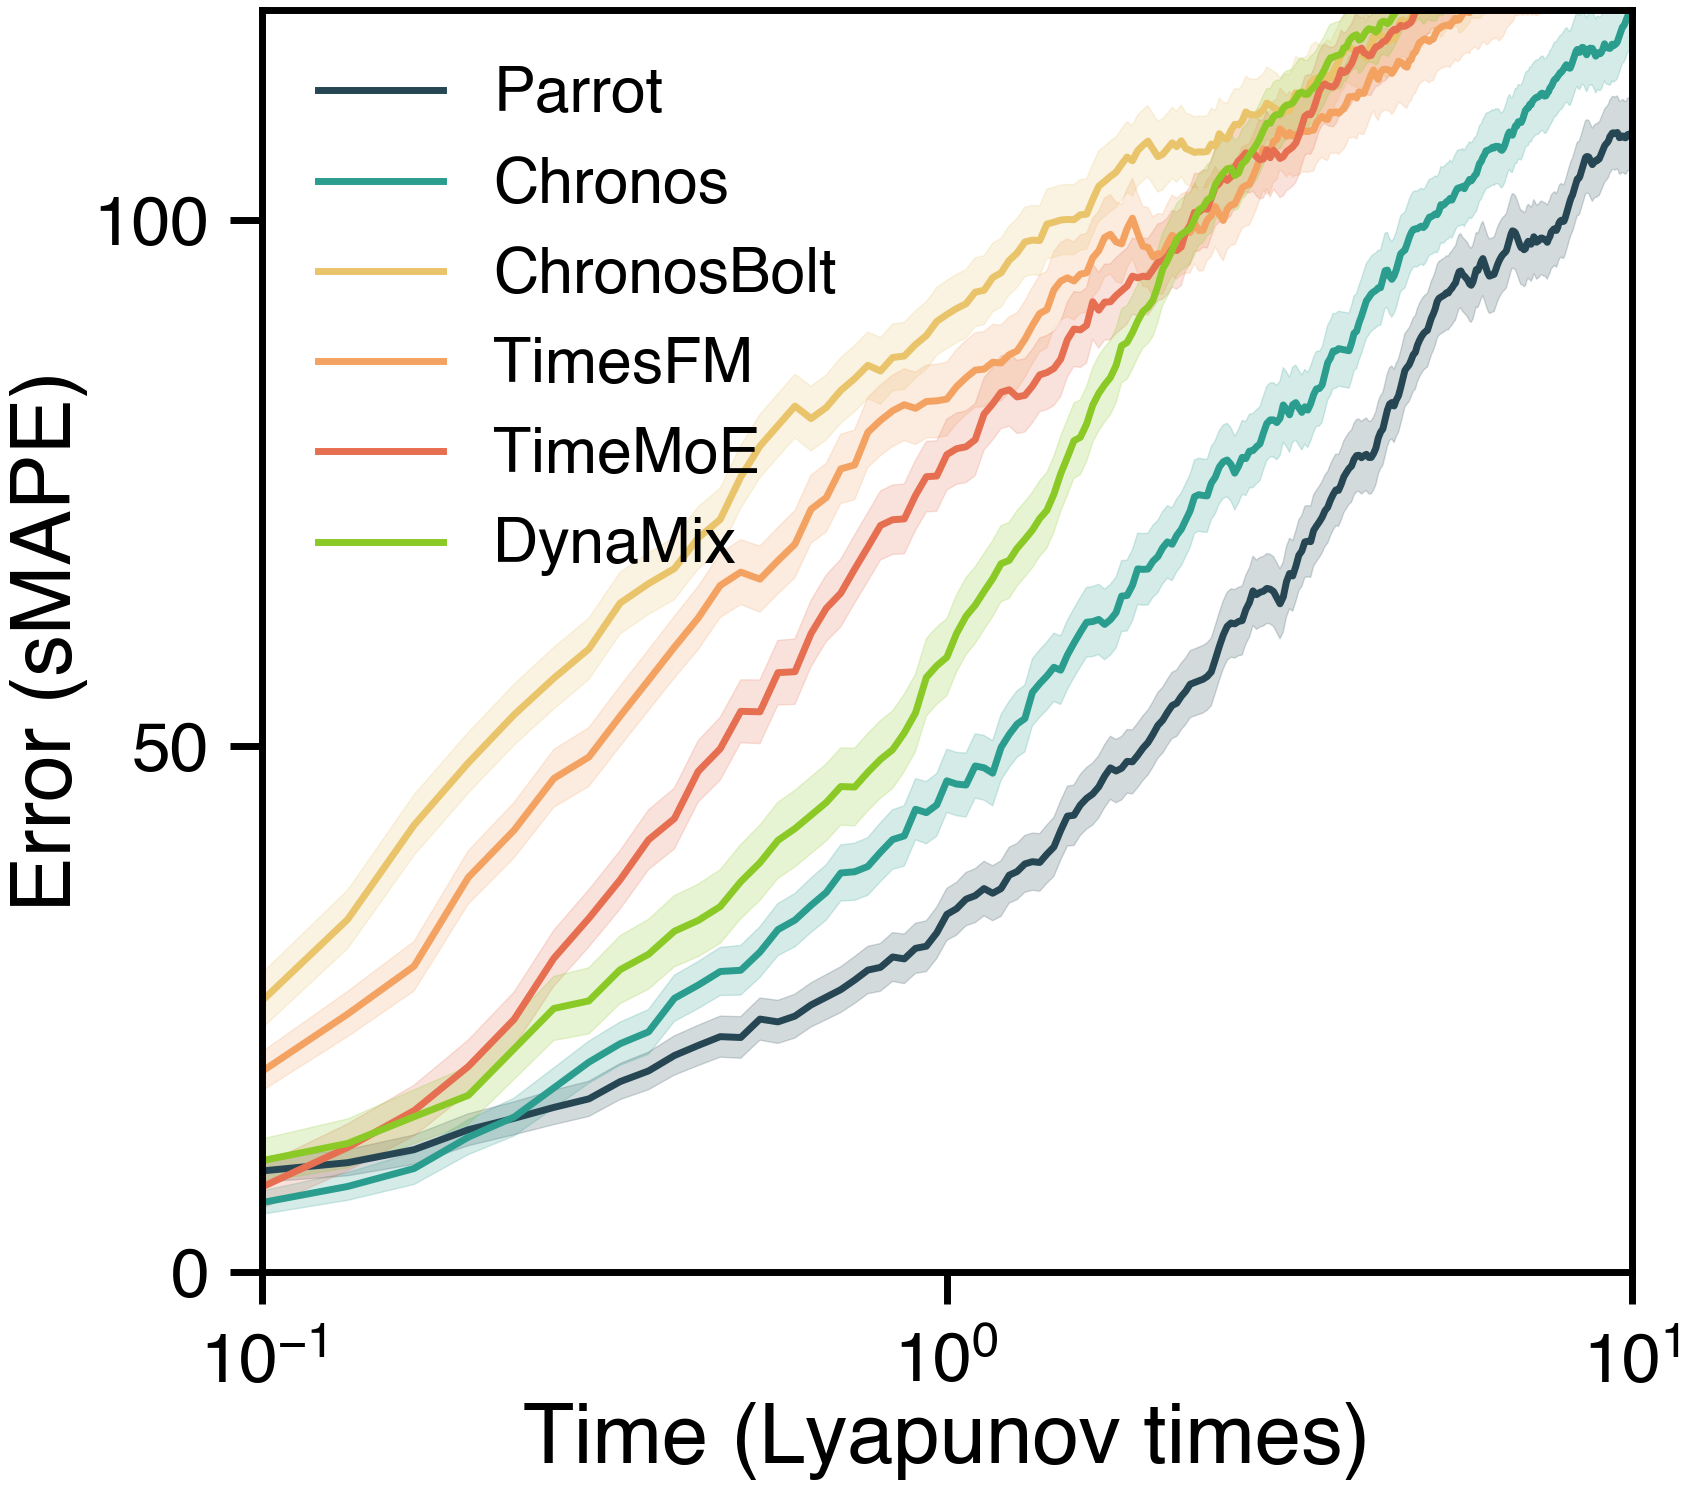

In [14]:
colors = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51", "#8ac926", "#1982c4", "#6a4c93"]

time = np.arange(1/granularity, (forecast_length+1)/granularity, 1/granularity)

# Plot Average VPT vs. Context Length for each equation
fig = plt.figure()
ax = fig.add_subplot(111)

for axis in ['bottom','left']:
  ax.spines[axis].set_linewidth(5)
for axis in ['top','right']:
  ax.spines[axis].set_linewidth(5)
  #ax.spines[axis].set_visible(False)

ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()

fig.set_size_inches(17,15)
plt.xticks(fontsize = 50)
plt.yticks(fontsize = 50)
plt.xlabel(r'Time (Lyapunov times)', fontname="Helvetica", fontsize = 60)
plt.ylabel(r'Error (sMAPE)', fontname="Helvetica", fontsize = 60)
  
context_length = 512

smape_trjs = [Parrot_median_smape[(equation_name, context_length)] for equation_name, ctx in Parrot_median_smape.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[0], label='Parrot')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[0])
print(f"Parrot median sMAPE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

smape_trjs = [median_smape[(equation_name, context_length)] for equation_name, ctx in median_smape.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[1], label='Chronos')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[1])
print(f"Chronos median sMAPE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

smape_trjs = [ChronosBolt_median_smape[(equation_name, context_length)] for equation_name, ctx in ChronosBolt_median_smape.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[2], label='ChronosBolt')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[2])
print(f"ChronosBolt median sMAPE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

smape_trjs = [TimesFM_median_smape[(equation_name, context_length)] for equation_name, ctx in TimesFM_median_smape.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[3], label='TimesFM')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[3])
print(f"TimesFM median sMAPE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

smape_trjs = [TimeMoE_median_smape[(equation_name, context_length)] for equation_name, ctx in TimeMoE_median_smape.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[4], label='TimeMoE')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[4])
print(f"TimeMoE median sMAPE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

smape_trjs = [dynamix_median_smape[(equation_name, context_length)] for equation_name, ctx in dynamix_median_smape.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[5], label='DynaMix')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[5])
print(f"DynaMix median sMAPE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

plt.xscale('log')
#plt.yscale('log')

plt.xlim([time[0], time[-1]])
plt.xlim([1e-1, time[-1]])
plt.ylim([0, 120])

plt.yticks([0, 50, 100])

plt.legend(loc='upper left', frameon=False, prop={'size':45, 'family': 'Helvetica'}, ncol=1)

plt.gca().tick_params(axis='y', pad=15, size=23, width=5)
plt.gca().tick_params(axis='x', pad=20, size=23, width=5)

fig.set_tight_layout(True)
plt.savefig(f'smape_rolling_compare_normalized.pdf', bbox_inches='tight')

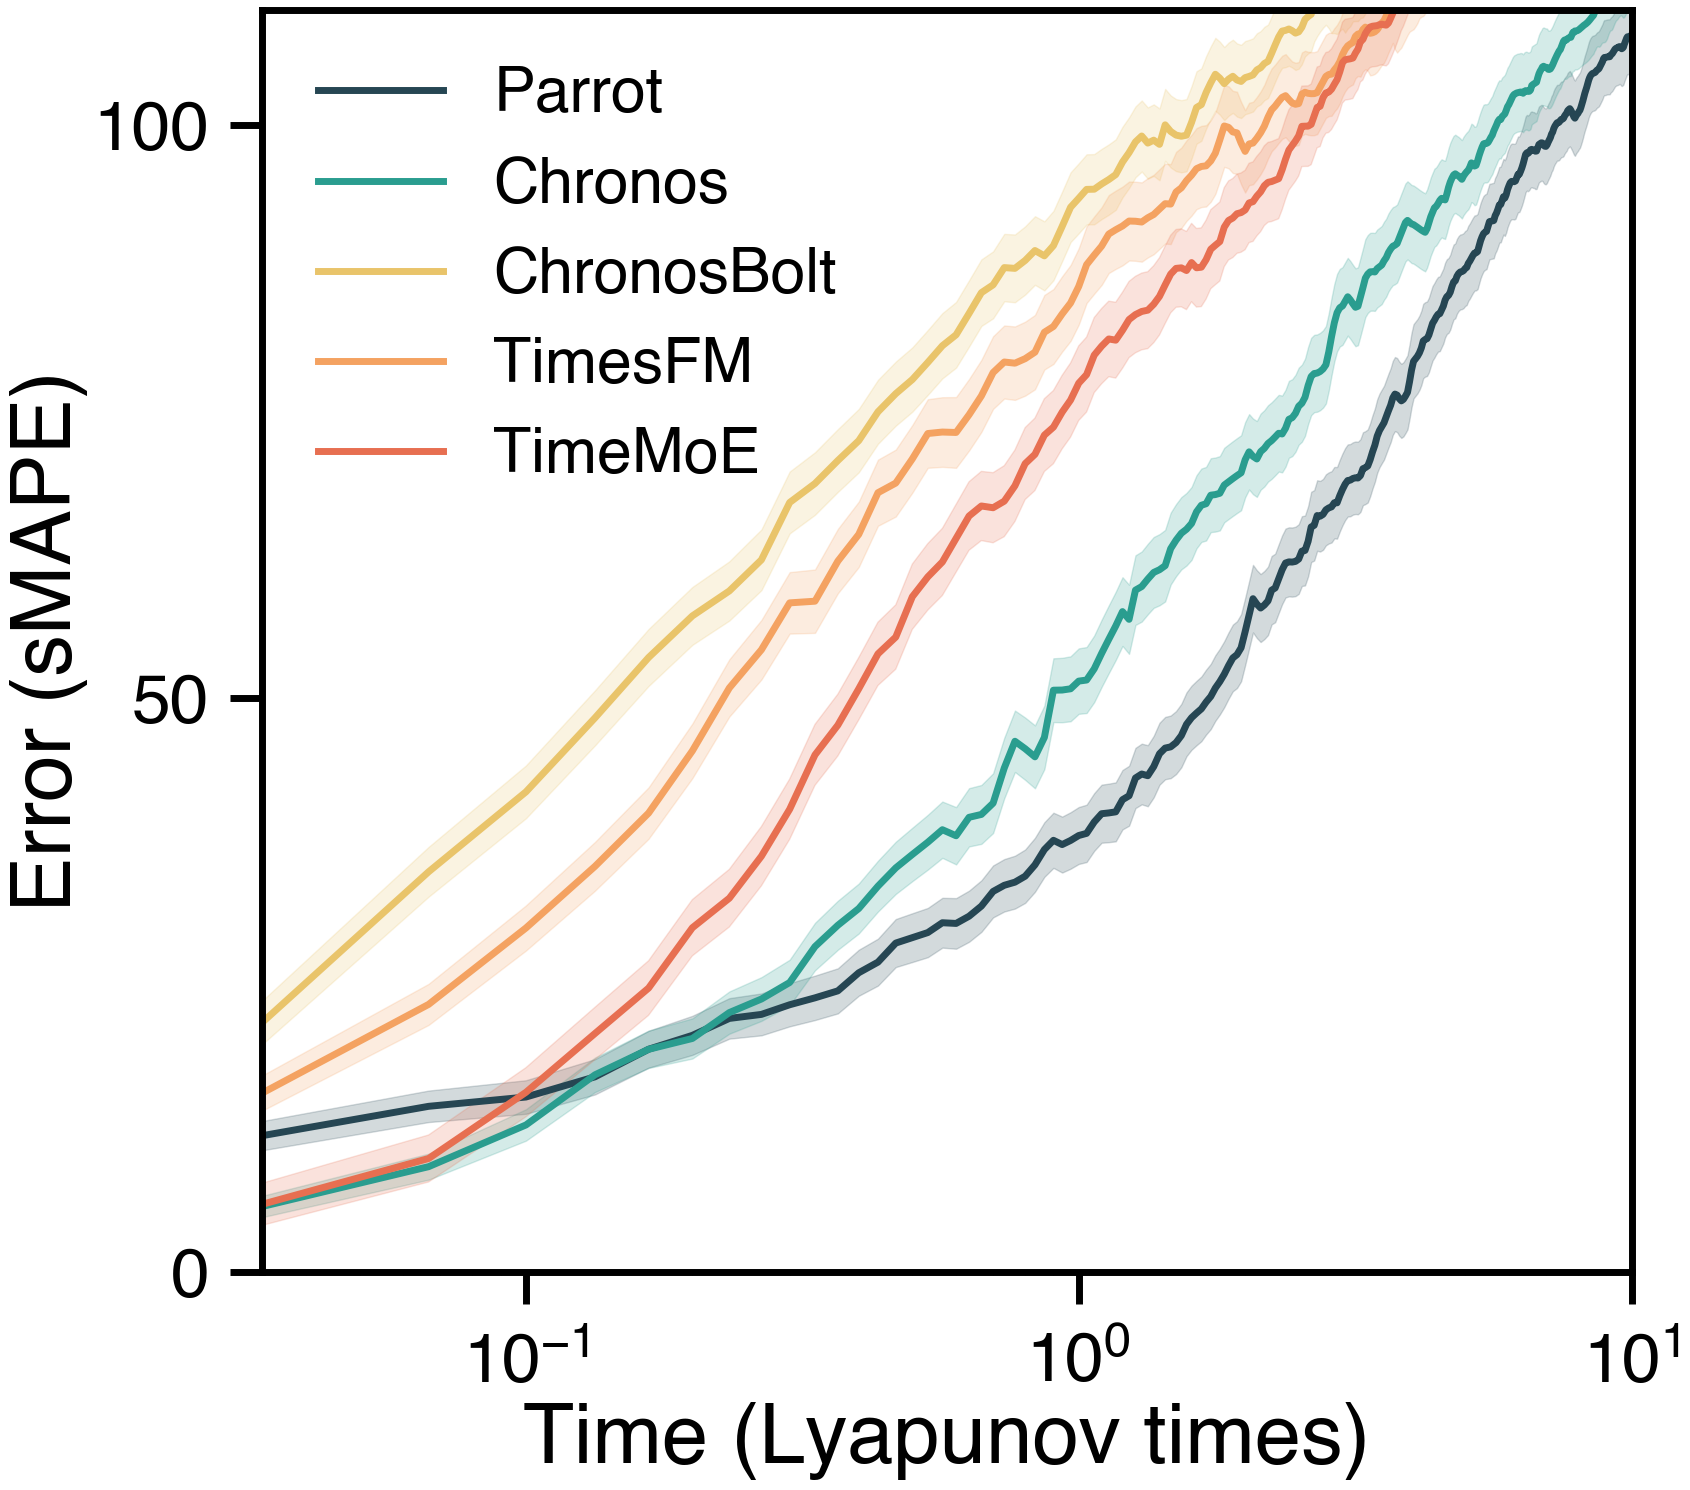

In [15]:
colors = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51"]

time = np.arange(1/granularity, (forecast_length+1)/granularity, 1/granularity)

# Plot Average VPT vs. Context Length for each equation
fig = plt.figure()
ax = fig.add_subplot(111)

for axis in ['bottom','left']:
  ax.spines[axis].set_linewidth(5)
for axis in ['top','right']:
  ax.spines[axis].set_linewidth(5)
  #ax.spines[axis].set_visible(False)

ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()

fig.set_size_inches(17,15)
plt.xticks(fontsize = 50)
plt.yticks(fontsize = 50)
plt.xlabel(r'Time (Lyapunov times)', fontname="Helvetica", fontsize = 60)
plt.ylabel(r'Error (sMAPE)', fontname="Helvetica", fontsize = 60)
  
context_length = 512

smape_trjs = [Parrot_median_smape_2[(equation_name, context_length)] for equation_name, ctx in Parrot_median_smape_2.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[0], label='Parrot')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[0])

smape_trjs = [median_smape_2[(equation_name, context_length)] for equation_name, ctx in median_smape_2.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[1], label='Chronos')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[1])

smape_trjs = [ChronosBolt_median_smape_2[(equation_name, context_length)] for equation_name, ctx in ChronosBolt_median_smape_2.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[2], label='ChronosBolt')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[2])

smape_trjs = [TimesFM_median_smape_2[(equation_name, context_length)] for equation_name, ctx in TimesFM_median_smape_2.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[3], label='TimesFM')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[3])

smape_trjs = [TimeMoE_median_smape_2[(equation_name, context_length)] for equation_name, ctx in TimeMoE_median_smape_2.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[4], label='TimeMoE')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[4])

plt.xscale('log')
#plt.yscale('log')

plt.xlim([time[0], time[-1]])
plt.ylim([0, 110])

plt.yticks([0, 50, 100])

plt.legend(loc='upper left', frameon=False, prop={'size':45, 'family': 'Helvetica'}, ncol=1)

plt.gca().tick_params(axis='y', pad=15, size=23, width=5)
plt.gca().tick_params(axis='x', pad=20, size=23, width=5)

fig.set_tight_layout(True)
#plt.savefig(f'smape_rolling_compare_2.pdf', bbox_inches='tight')

Parrot median MSE @ 1 Lyapunov Time: 0.04353127181050642, 0.02573765241933967
Chronos median MSE @ 1 Lyapunov Time: 0.1054518949506888, 0.0320912440623285
ChronosBolt median MSE @ 1 Lyapunov Time: 0.44573483604954145, 0.027421243448208725
TimesFM median MSE @ 1 Lyapunov Time: 0.3217060150314719, 0.02684111712515231
TimeMoE median MSE @ 1 Lyapunov Time: 0.23577743985954203, 0.023892188190369867
DynaMix median MSE @ 1 Lyapunov Time: 0.1823782778644889, 0.049269784666630685


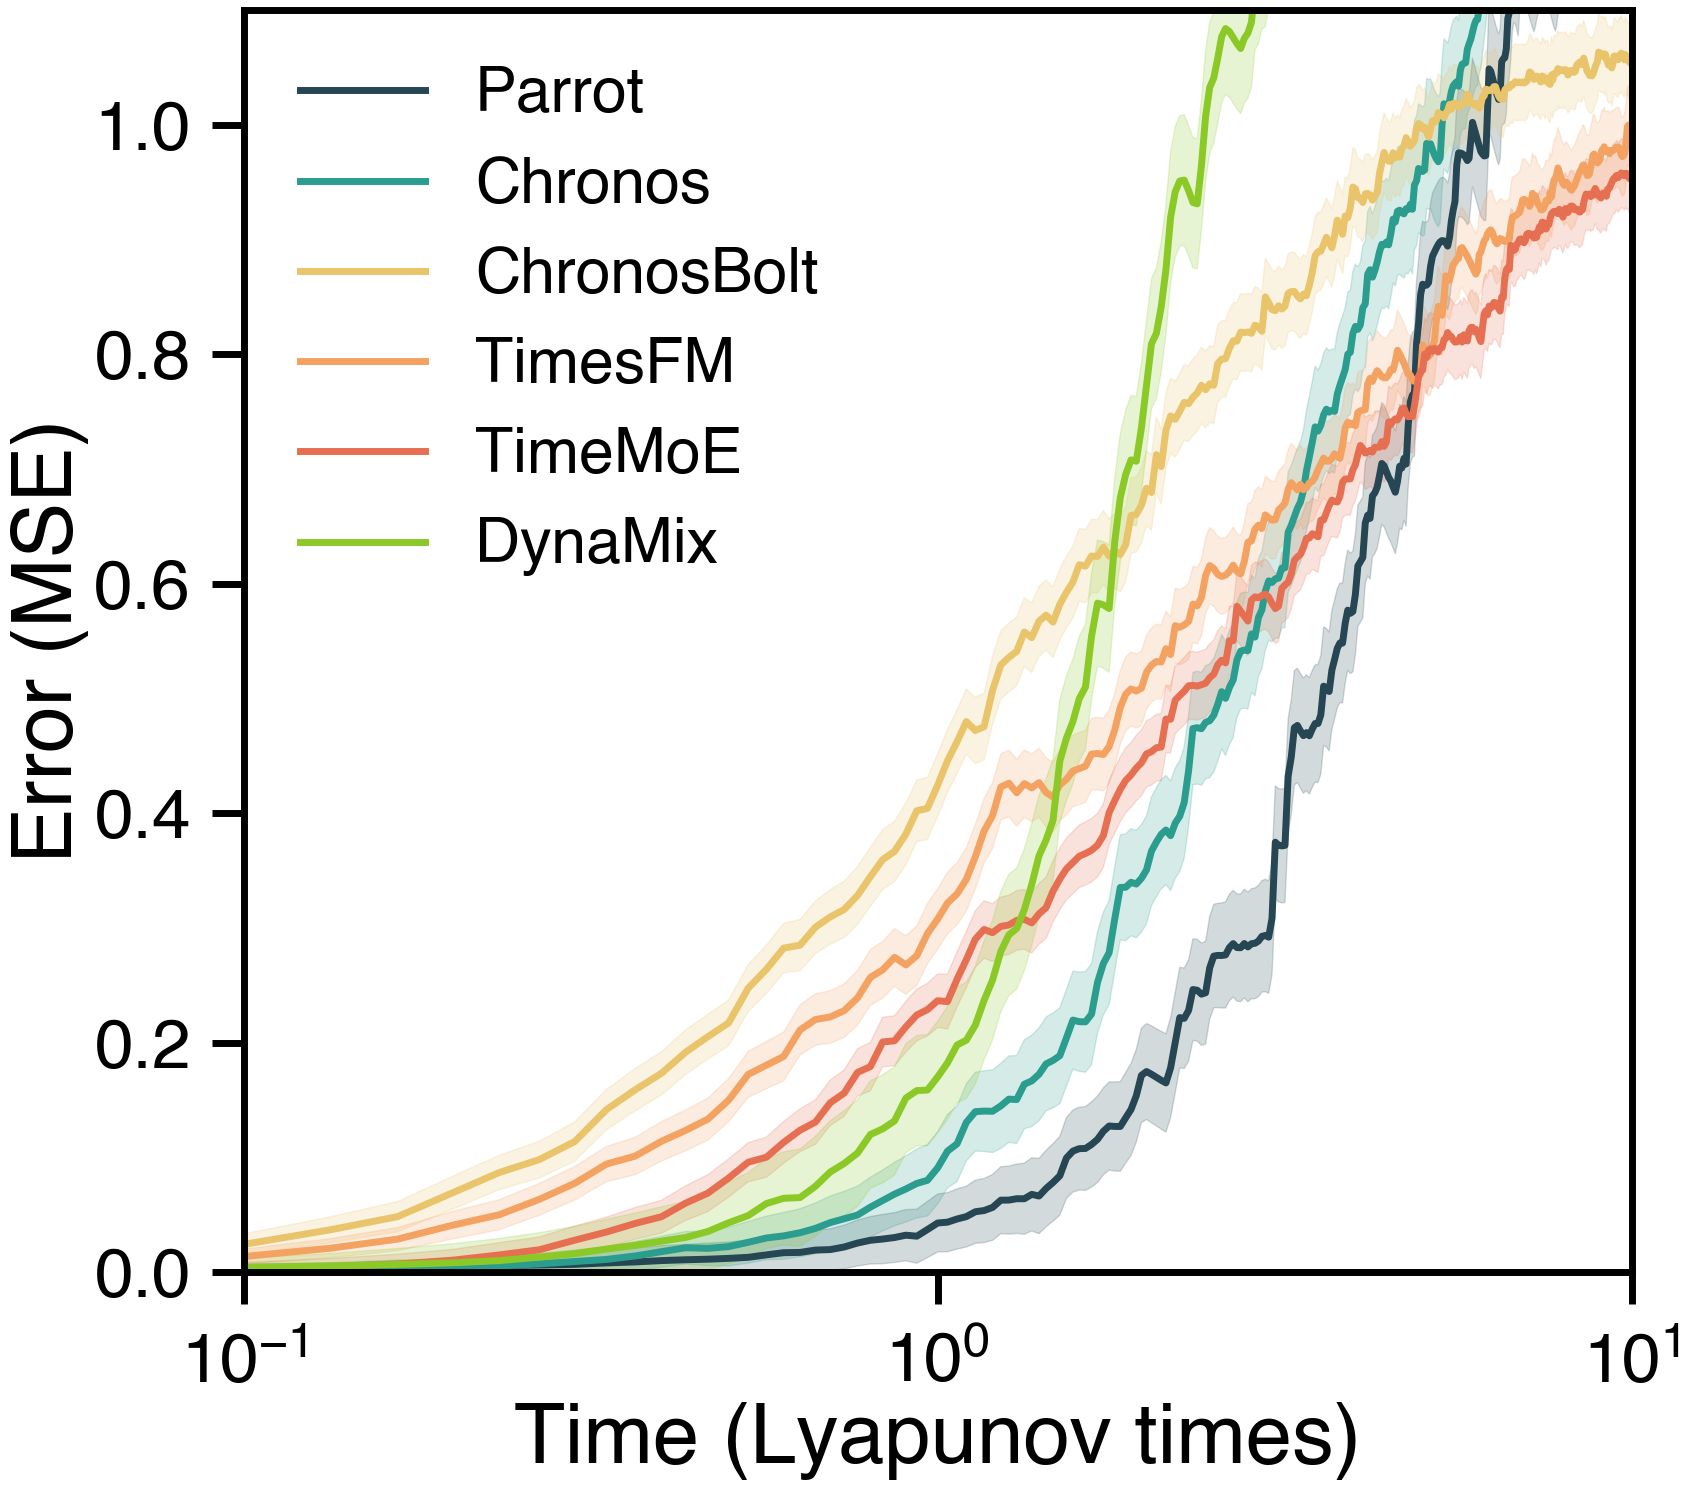

In [16]:
colors = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51", "#8ac926", "#1982c4", "#6a4c93"]

time = np.arange(1/granularity, (forecast_length+1)/granularity, 1/granularity)

# Plot Average VPT vs. Context Length for each equation
fig = plt.figure()
ax = fig.add_subplot(111)

for axis in ['bottom','left']:
  ax.spines[axis].set_linewidth(5)
for axis in ['top','right']:
  ax.spines[axis].set_linewidth(5)
  #ax.spines[axis].set_visible(False)

ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()

fig.set_size_inches(17,15)
plt.xticks(fontsize = 50)
plt.yticks(fontsize = 50)
plt.xlabel(r'Time (Lyapunov times)', fontname="Helvetica", fontsize = 60)
plt.ylabel(r'Error (MSE)', fontname="Helvetica", fontsize = 60)
  
context_length = 512

smape_trjs = [Parrot_median_mse[(equation_name, context_length)] for equation_name, ctx in Parrot_median_mse.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[0], label='Parrot')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[0])
print(f"Parrot median MSE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

smape_trjs = [median_mse[(equation_name, context_length)] for equation_name, ctx in median_mse.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[1], label='Chronos')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[1])
print(f"Chronos median MSE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

smape_trjs = [ChronosBolt_median_mse[(equation_name, context_length)] for equation_name, ctx in ChronosBolt_median_mse.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[2], label='ChronosBolt')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[2])
print(f"ChronosBolt median MSE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

smape_trjs = [TimesFM_median_mse[(equation_name, context_length)] for equation_name, ctx in TimesFM_median_mse.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[3], label='TimesFM')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[3])
print(f"TimesFM median MSE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

smape_trjs = [TimeMoE_median_mse[(equation_name, context_length)] for equation_name, ctx in TimeMoE_median_mse.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[4], label='TimeMoE')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[4])
print(f"TimeMoE median MSE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

smape_trjs = [dynamix_median_mse[(equation_name, context_length)] for equation_name, ctx in dynamix_median_mse.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[5], label='DynaMix')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[5])
print(f"DynaMix median MSE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

plt.xscale('log')
#plt.yscale('log')

#plt.xlim([time[0], time[-1]])
plt.xlim([1e-1, time[-1]])
plt.ylim([0, 1.1])

#plt.yticks([0, 50, 100])

plt.legend(loc='upper left', frameon=False, prop={'size':45, 'family': 'Helvetica'}, ncol=1)

plt.gca().tick_params(axis='y', pad=15, size=23, width=5)
plt.gca().tick_params(axis='x', pad=20, size=23, width=5)

fig.set_tight_layout(True)
plt.savefig(f'mse_rolling_compare_normalized.pdf', bbox_inches='tight')

In [17]:
smape_trjs = [Parrot_median_mse[(equation_name, context_length)] for equation_name, ctx in Parrot_median_mse.keys() if ctx == context_length]
smape_trj = np.mean(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)
print(f"Parrot mean MSE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

smape_trjs = [median_mse[(equation_name, context_length)] for equation_name, ctx in median_mse.keys() if ctx == context_length]
smape_trj = np.mean(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)
print(f"Chronos mean MSE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

smape_trjs = [ChronosBolt_median_mse[(equation_name, context_length)] for equation_name, ctx in ChronosBolt_median_mse.keys() if ctx == context_length]
smape_trj = np.mean(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)
print(f"ChronosBolt mean MSE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

smape_trjs = [TimesFM_median_mse[(equation_name, context_length)] for equation_name, ctx in TimesFM_median_mse.keys() if ctx == context_length]
smape_trj = np.mean(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)
print(f"TimesFM mean MSE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

smape_trjs = [TimeMoE_median_mse[(equation_name, context_length)] for equation_name, ctx in TimeMoE_median_mse.keys() if ctx == context_length]
smape_trj = np.mean(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)
print(f"TimeMoE mean MSE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

Parrot mean MSE @ 1 Lyapunov Time: 0.16430913922117005, 0.2945808963929859
Chronos mean MSE @ 1 Lyapunov Time: 0.268284055885609, 0.3673010765792818
ChronosBolt mean MSE @ 1 Lyapunov Time: 0.47288747465221, 0.31385047647600733
TimesFM mean MSE @ 1 Lyapunov Time: 0.3941553724226507, 0.3072106272200312
TimeMoE mean MSE @ 1 Lyapunov Time: 0.3146934228231765, 0.2734585928520998


Parrot median MAE @ 1 Lyapunov Time: 0.14223827837924397, 0.0178343645898811
Chronos median MAE @ 1 Lyapunov Time: 0.2353063598097275, 0.021209570392826064
ChronosBolt median MAE @ 1 Lyapunov Time: 0.5244326788987749, 0.019480280281853782
TimesFM median MAE @ 1 Lyapunov Time: 0.4272080702493014, 0.01995607926940087
TimeMoE median MAE @ 1 Lyapunov Time: 0.3870609069196024, 0.018471803686664325
DynaMix median MAE @ 1 Lyapunov Time: 0.31579016371805724, 0.028928102955431342


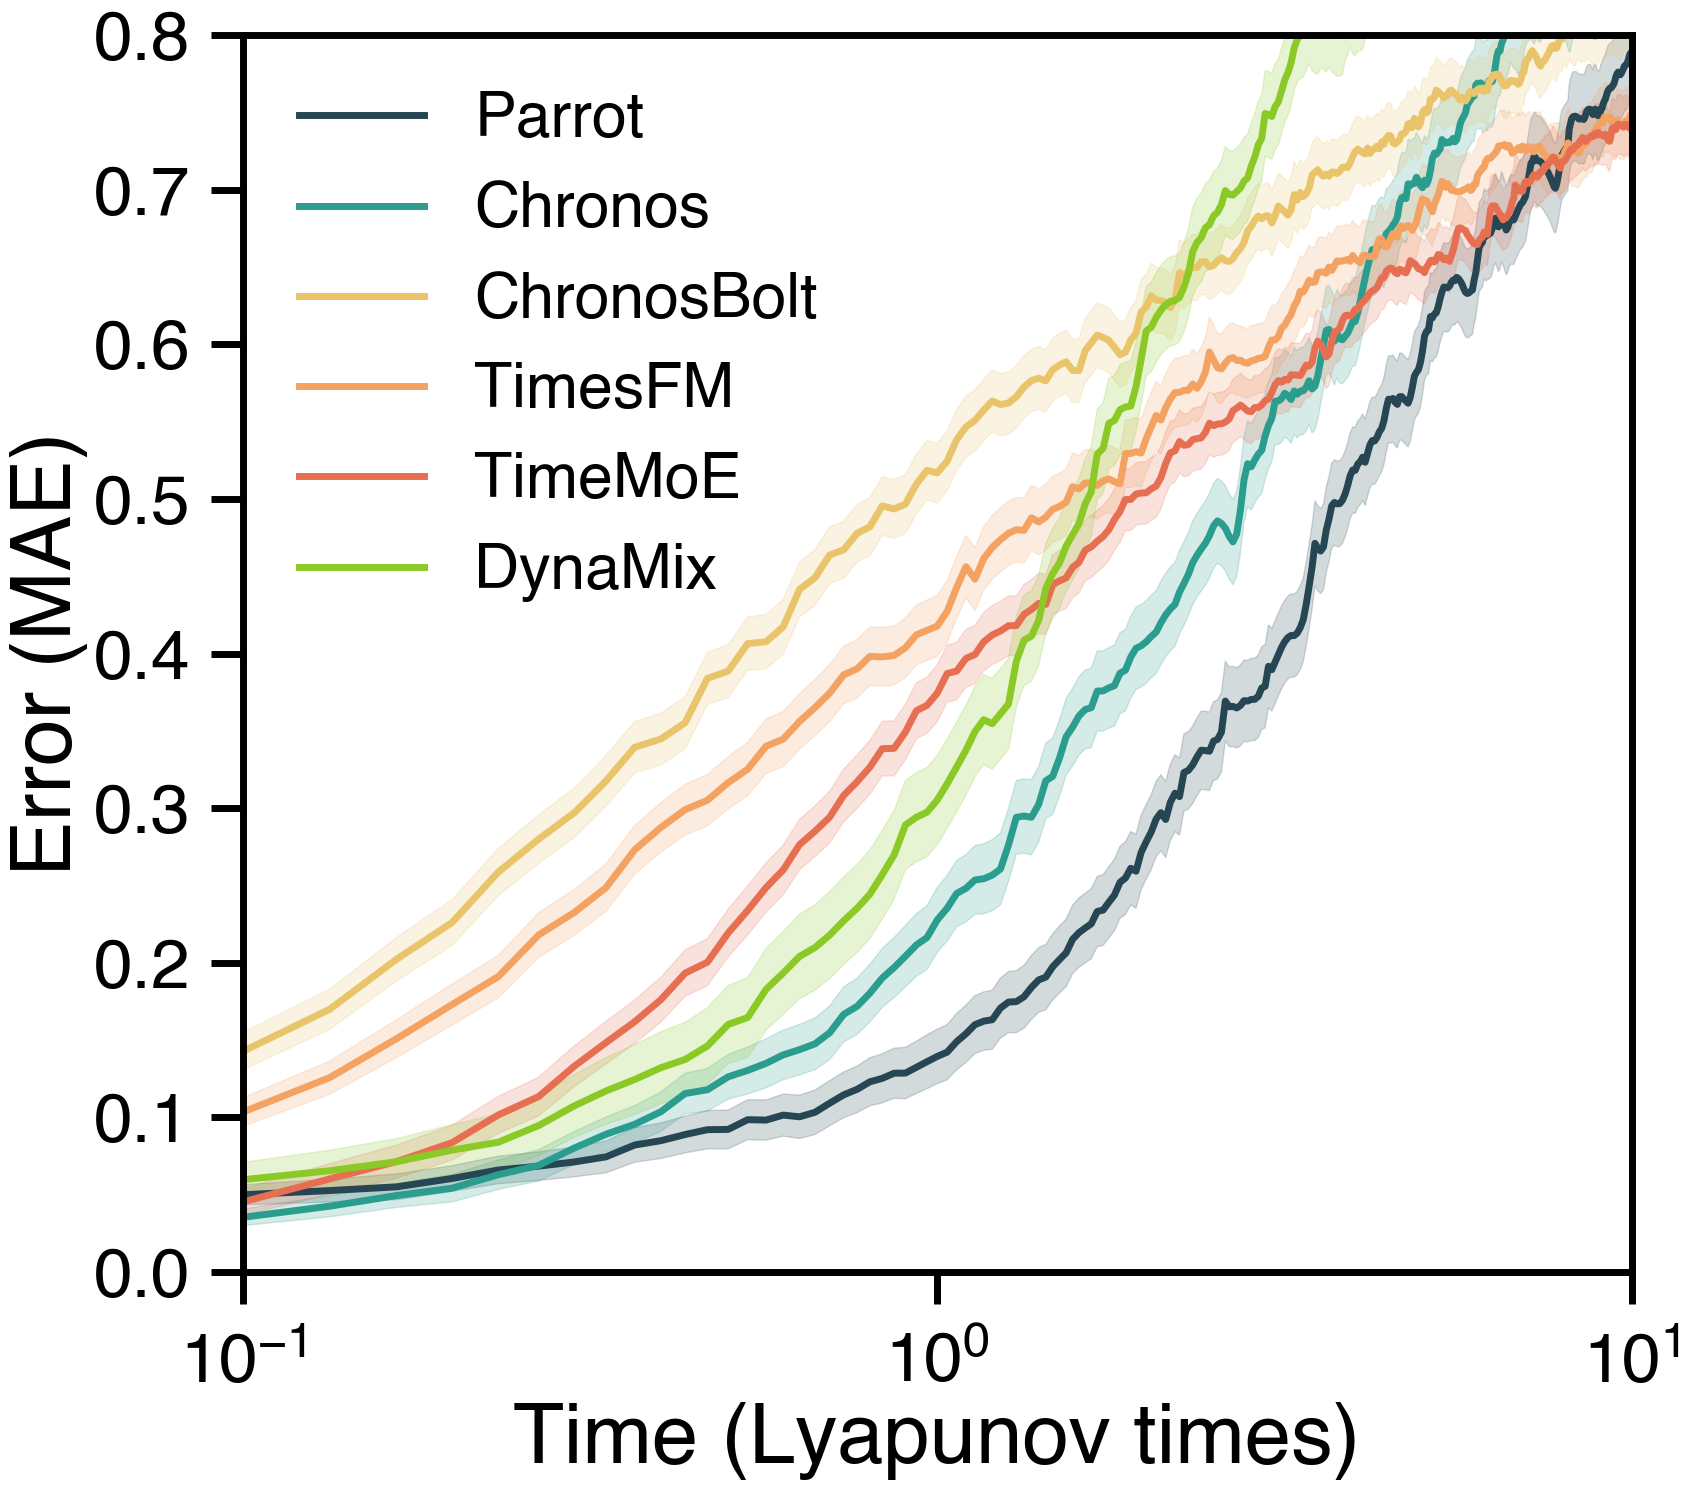

In [18]:
colors = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51", "#8ac926", "#1982c4", "#6a4c93"]

time = np.arange(1/granularity, (forecast_length+1)/granularity, 1/granularity)

# Plot Average VPT vs. Context Length for each equation
fig = plt.figure()
ax = fig.add_subplot(111)

for axis in ['bottom','left']:
  ax.spines[axis].set_linewidth(5)
for axis in ['top','right']:
  ax.spines[axis].set_linewidth(5)
  #ax.spines[axis].set_visible(False)

ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()

fig.set_size_inches(17,15)
plt.xticks(fontsize = 50)
plt.yticks(fontsize = 50)
plt.xlabel(r'Time (Lyapunov times)', fontname="Helvetica", fontsize = 60)
plt.ylabel(r'Error (MAE)', fontname="Helvetica", fontsize = 60)
  
context_length = 512

smape_trjs = [Parrot_median_mae[(equation_name, context_length)] for equation_name, ctx in Parrot_median_mae.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[0], label='Parrot')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[0])
print(f"Parrot median MAE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

smape_trjs = [median_mae[(equation_name, context_length)] for equation_name, ctx in median_mae.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[1], label='Chronos')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[1])
print(f"Chronos median MAE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

smape_trjs = [ChronosBolt_median_mae[(equation_name, context_length)] for equation_name, ctx in ChronosBolt_median_mae.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[2], label='ChronosBolt')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[2])
print(f"ChronosBolt median MAE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

smape_trjs = [TimesFM_median_mae[(equation_name, context_length)] for equation_name, ctx in TimesFM_median_mae.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[3], label='TimesFM')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[3])
print(f"TimesFM median MAE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

smape_trjs = [TimeMoE_median_mae[(equation_name, context_length)] for equation_name, ctx in TimeMoE_median_mae.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[4], label='TimeMoE')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[4])
print(f"TimeMoE median MAE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

smape_trjs = [dynamix_median_mae[(equation_name, context_length)] for equation_name, ctx in dynamix_median_mae.keys() if ctx == context_length]
smape_trj = np.median(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[5], label='DynaMix')
ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[5])
print(f"DynaMix median MAE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

plt.xscale('log')
#plt.yscale('log')

#plt.xlim([time[0], time[-1]])
plt.xlim([1e-1, time[-1]])
plt.ylim([0, .8])

#plt.yticks([0, 50, 100])

plt.legend(loc='upper left', frameon=False, prop={'size':45, 'family': 'Helvetica'}, ncol=1)

plt.gca().tick_params(axis='y', pad=15, size=23, width=5)
plt.gca().tick_params(axis='x', pad=20, size=23, width=5)

fig.set_tight_layout(True)
plt.savefig(f'mae_rolling_compare_normalized.pdf', bbox_inches='tight')

In [19]:
smape_trjs = [Parrot_median_mae[(equation_name, context_length)] for equation_name, ctx in Parrot_median_mae.keys() if ctx == context_length]
smape_trj = np.mean(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)
print(f"Parrot mean MAE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

smape_trjs = [median_mae[(equation_name, context_length)] for equation_name, ctx in median_mae.keys() if ctx == context_length]
smape_trj = np.mean(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)
print(f"Chronos mean MAE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

smape_trjs = [ChronosBolt_median_mae[(equation_name, context_length)] for equation_name, ctx in ChronosBolt_median_mae.keys() if ctx == context_length]
smape_trj = np.mean(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)
print(f"ChronosBolt mean MAE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

smape_trjs = [TimesFM_median_mae[(equation_name, context_length)] for equation_name, ctx in TimesFM_median_mae.keys() if ctx == context_length]
smape_trj = np.mean(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)
print(f"TimesFM mean MAE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

smape_trjs = [TimeMoE_median_mae[(equation_name, context_length)] for equation_name, ctx in TimeMoE_median_mae.keys() if ctx == context_length]
smape_trj = np.mean(smape_trjs, axis=0)
smape_std = np.std(smape_trjs, axis=0)
print(f"TimeMoE mean MAE @ 1 Lyapunov Time: {smape_trj[granularity]}, {smape_std[granularity]}")

Parrot mean MAE @ 1 Lyapunov Time: 0.21858314933542466, 0.20412363264097924
Chronos mean MAE @ 1 Lyapunov Time: 0.2965794277744147, 0.2427546287684747
ChronosBolt mean MAE @ 1 Lyapunov Time: 0.4907785175071864, 0.22296199878366077
TimesFM mean MAE @ 1 Lyapunov Time: 0.4395758968271874, 0.2284077671066947
TimeMoE mean MAE @ 1 Lyapunov Time: 0.37727393928279934, 0.21141945657499267


131


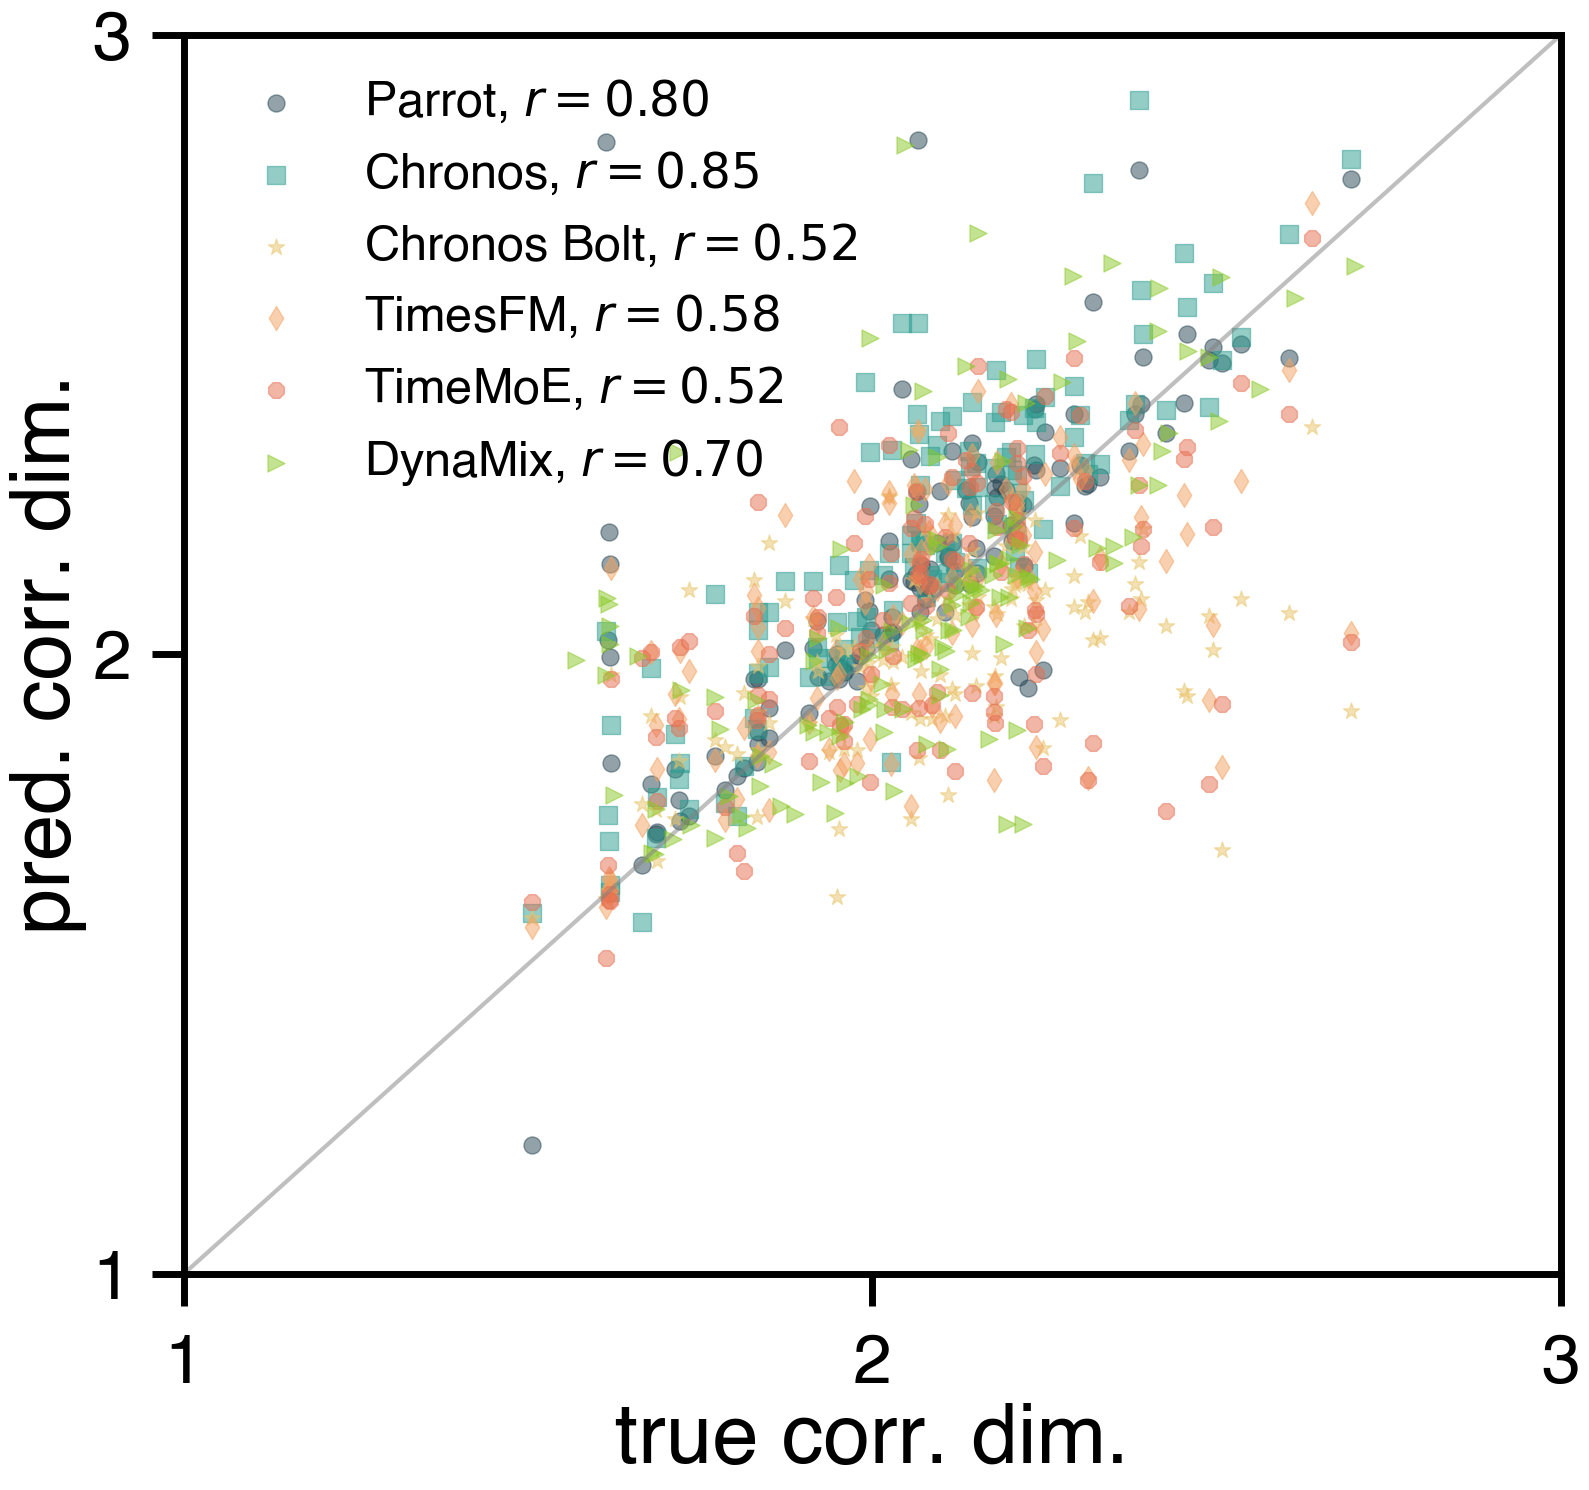

In [20]:
from scipy.stats import spearmanr

# Extract unique equation names and context lengths
included_equations = equation_names
print(len(included_equations))

# Plot Average VPT vs. Context Length for each equation
fig = plt.figure()
ax = fig.add_subplot(111)

for axis in ['bottom','left']:
  ax.spines[axis].set_linewidth(5)
for axis in ['top','right']:
  ax.spines[axis].set_linewidth(5)
  #ax.spines[axis].set_visible(False)

ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()

fig.set_size_inches(16,15)
plt.xticks(fontsize = 50)
plt.yticks(fontsize = 50)
plt.xlabel(r'true corr. dim.',fontsize = 60)
plt.ylabel(r'pred. corr. dim.',fontsize = 60)

context_length = 512

# Extract predicted and true cdim values for context_length=512
all_cdim_pred_med = []
all_cdim_true_med = []
for (eq_name, ctx), arr in Parrot_median_cdim.items():
  if ctx == context_length:
    all_cdim_pred_med.append(arr[0])
    all_cdim_true_med.append(arr[1])
scorr_val_med = spearmanr(all_cdim_pred_med, all_cdim_true_med).statistic
#print(f"Spearman correlation for median cdim: {scorr_val_med}")
plt.scatter(all_cdim_true_med, all_cdim_pred_med, color=colors[0], marker='o', s=150, alpha=.5, label=r'Parrot, $r = {:.2f}$'.format(scorr_val_med))

all_cdim_pred_med = []
all_cdim_true_med = []
for (eq_name, ctx), arr in median_cdim.items():
  if ctx == context_length:
    all_cdim_pred_med.append(arr[0])
    all_cdim_true_med.append(arr[1])
scorr_val_med = spearmanr(all_cdim_pred_med, all_cdim_true_med).statistic
plt.scatter(all_cdim_true_med, all_cdim_pred_med, color=colors[1], marker='s', s=150, alpha=.5, label=r'Chronos, $r = {:.2f}$'.format(scorr_val_med))

all_cdim_pred_med = []
all_cdim_true_med = []
for (eq_name, ctx), arr in ChronosBolt_median_cdim.items():
  if ctx == context_length:
    all_cdim_pred_med.append(arr[0])
    all_cdim_true_med.append(arr[1])
scorr_val_med = spearmanr(all_cdim_pred_med, all_cdim_true_med).statistic
plt.scatter(all_cdim_true_med, all_cdim_pred_med, color=colors[2], marker='*', s=150, alpha=.5, label=r'Chronos Bolt, $r = {:.2f}$'.format(scorr_val_med))

all_cdim_pred_med = []
all_cdim_true_med = []
for (eq_name, ctx), arr in TimesFM_median_cdim.items():
  if ctx == context_length:
    all_cdim_pred_med.append(arr[0])
    all_cdim_true_med.append(arr[1])
scorr_val_med = spearmanr(all_cdim_pred_med, all_cdim_true_med).statistic
plt.scatter(all_cdim_true_med, all_cdim_pred_med, color=colors[3], marker='d', s=150, alpha=.5, label=r'TimesFM, $r = {:.2f}$'.format(scorr_val_med))

all_cdim_pred_med = []
all_cdim_true_med = []
for (eq_name, ctx), arr in TimeMoE_median_cdim.items():
  if ctx == context_length:
    all_cdim_pred_med.append(arr[0])
    all_cdim_true_med.append(arr[1])
scorr_val_med = spearmanr(all_cdim_pred_med, all_cdim_true_med).statistic
plt.scatter(all_cdim_true_med, all_cdim_pred_med, color=colors[4], marker='8', s=150, alpha=.5, label=r'TimeMoE, $r = {:.2f}$'.format(scorr_val_med))

all_cdim_pred_med = []
all_cdim_true_med = []
for (eq_name, ctx), arr in dynamix_median_cdim.items():
  if ctx == context_length:
    all_cdim_pred_med.append(arr[0])
    all_cdim_true_med.append(arr[1])
scorr_val_med = spearmanr(all_cdim_pred_med, all_cdim_true_med).statistic
plt.scatter(all_cdim_true_med, all_cdim_pred_med, color=colors[5], marker='>', s=150, alpha=.5, label=r'DynaMix, $r = {:.2f}$'.format(scorr_val_med))

plt.plot([0,3], [0,3], lw=3, ls='-', alpha=.5, color='gray')

#plt.xscale('log')
#plt.yscale('log')
plt.xlim([1, 3])
plt.ylim([1, 3])

plt.xticks([1, 2, 3])
plt.yticks([1, 2, 3])

plt.legend(loc='upper left', frameon=False, prop={'size':35}, ncol=1)

plt.gca().tick_params(axis='y', pad=15, size=23, width=5)
plt.gca().tick_params(axis='x', pad=20, size=23, width=5)

fig.set_tight_layout(True)
plt.savefig(f'cdim_compare.pdf', bbox_inches='tight')

Parrot KL values: 0.12230041220921092, 0.19444906405682666
Chronos KL values: 0.17347153593848277, 0.20875901076993889
ChronosBolt KL values: 0.34642539858351573, 0.2966884438259311
TimesFM KL values: 0.3453277229587677, 0.2978224757120756
TimeMoE KL values: 0.35403717914688254, 0.2903898631476769
DynaMix KL values: 0.20713252951953184, 0.2910384277836067
Moirai KL values: 0.3201169826566724, 0.28357170500202017
Panda KL values: 0.18262130593338377, 0.20656779004344308
Simplex KL values: 0.22763838115891477, 0.2685628579790926
ARIMA KL values: 0.6648733295126379, 0.3441014186659097


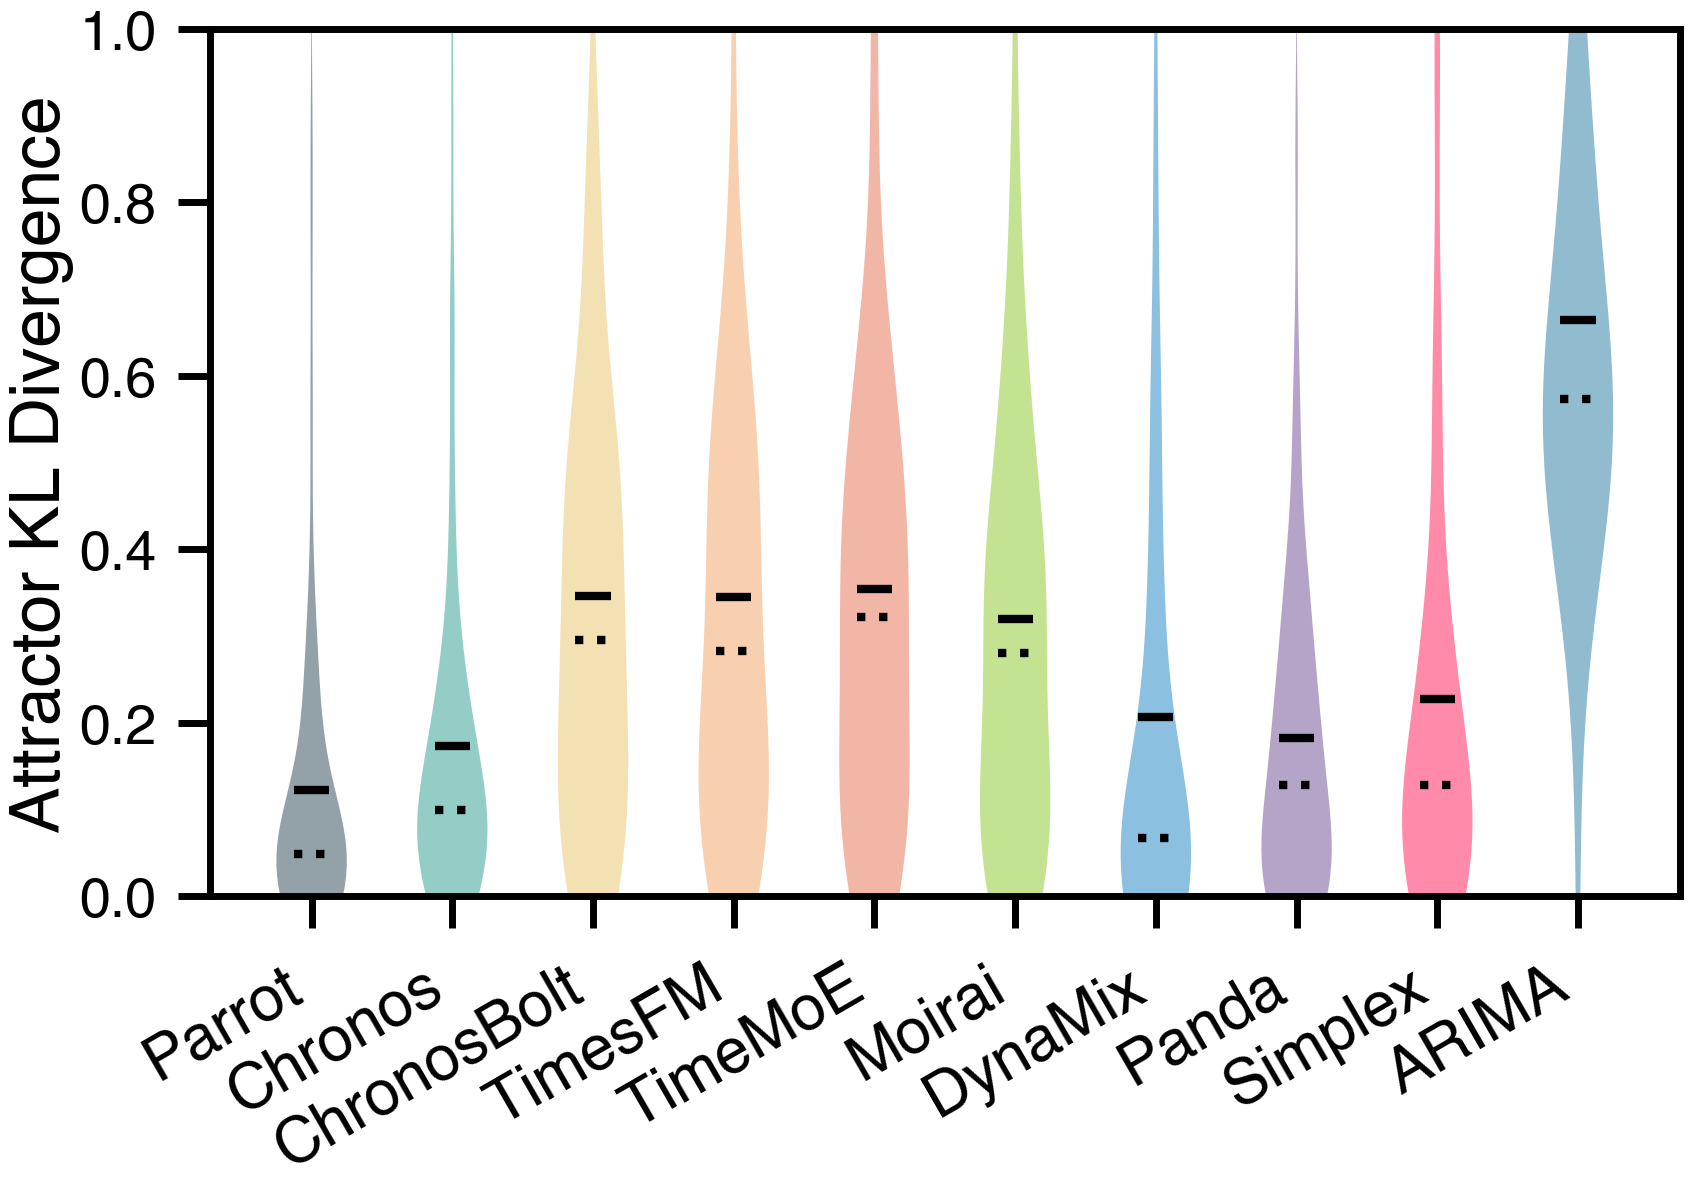

In [28]:
context_length = 512
Parrot_kl_values = [Parrot_median_kl[(equation_name, context_length)] for equation_name, ctx in Parrot_median_kl.keys() if ctx == context_length]
Chronos_kl_values = [median_kl[(equation_name, context_length)] for equation_name, ctx in median_kl.keys() if ctx == context_length]
ChronosBolt_kl_values = [ChronosBolt_median_kl[(equation_name, context_length)] for equation_name, ctx in ChronosBolt_median_kl.keys() if ctx == context_length]
TimesFM_kl_values = [TimesFM_median_kl[(equation_name, context_length)] for equation_name, ctx in TimesFM_median_kl.keys() if ctx == context_length]
TimeMoE_kl_values = [TimeMoE_median_kl[(equation_name, context_length)] for equation_name, ctx in TimeMoE_median_kl.keys() if ctx == context_length]
dynamix_kl_values = [dynamix_median_kl[(equation_name, context_length)] for equation_name, ctx in dynamix_median_kl.keys() if ctx == context_length]
moirai_kl_values = [Moirai_median_kl[(equation_name, context_length)] for equation_name, ctx in Moirai_median_kl.keys() if ctx == context_length]
panda_kl_values = [panda_median_kl[(equation_name, context_length)] for equation_name, ctx in panda_median_kl.keys() if ctx == context_length]
simplex_kl_values = [simplex_median_kl[(equation_name, context_length)] for equation_name, ctx in simplex_median_kl.keys() if ctx == context_length]
arima_kl_values = [arima_median_kl[(equation_name, context_length)] for equation_name, ctx in arima_median_kl.keys() if ctx == context_length]


fig = plt.figure()
ax = fig.add_subplot(111)

for axis in ['bottom','left']:
  ax.spines[axis].set_linewidth(5)
for axis in ['top','right']:
  ax.spines[axis].set_linewidth(5)
  #ax.spines[axis].set_visible(False)

ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()

fig.set_size_inches(17,12)
plt.xticks(fontsize = 40)
plt.yticks(fontsize = 40)

#plt.xlabel(['Parrot', 'Chronos', 'ChronosBolt', 'TimesFM', 'TimeMoE'],fontsize = 60)
plt.ylabel(r'Attractor KL Divergence',fontsize = 50)

# Remove NaN values from each KL list
Parrot_kl_values = [v for v in Parrot_kl_values if not np.isnan(v)]
Chronos_kl_values = [v for v in Chronos_kl_values if not np.isnan(v)]
ChronosBolt_kl_values = [v for v in ChronosBolt_kl_values if not np.isnan(v)]
TimesFM_kl_values = [v for v in TimesFM_kl_values if not np.isnan(v)]
TimeMoE_kl_values = [v for v in TimeMoE_kl_values if not np.isnan(v)]
dynamix_kl_values = [v for v in dynamix_kl_values if not np.isnan(v)]
moirai_kl_values = [v for v in moirai_kl_values if not np.isnan(v)]
panda_kl_values = [v for v in panda_kl_values if not np.isnan(v)]
simplex_kl_values = [v for v in simplex_kl_values if not np.isnan(v)]
arima_kl_values = [v for v in arima_kl_values if not np.isnan(v)]


print(f"Parrot KL values: {np.mean(Parrot_kl_values)}, {np.std(Parrot_kl_values)}")
print(f"Chronos KL values: {np.mean(Chronos_kl_values)}, {np.std(Chronos_kl_values)}")
print(f"ChronosBolt KL values: {np.mean(ChronosBolt_kl_values)}, {np.std(ChronosBolt_kl_values)}")
print(f"TimesFM KL values: {np.mean(TimesFM_kl_values)}, {np.std(TimesFM_kl_values)}")
print(f"TimeMoE KL values: {np.mean(TimeMoE_kl_values)}, {np.std(TimeMoE_kl_values)}")
print(f"DynaMix KL values: {np.mean(dynamix_kl_values)}, {np.std(dynamix_kl_values)}")
print(f"Moirai KL values: {np.mean(moirai_kl_values)}, {np.std(moirai_kl_values)}")
print(f"Panda KL values: {np.mean(panda_kl_values)}, {np.std(panda_kl_values)}")
print(f"Simplex KL values: {np.mean(simplex_kl_values)}, {np.std(simplex_kl_values)}")
print(f"ARIMA KL values: {np.mean(arima_kl_values)}, {np.std(arima_kl_values)}")

violin = ax.violinplot(
    [Parrot_kl_values, Chronos_kl_values, ChronosBolt_kl_values, TimesFM_kl_values, TimeMoE_kl_values, moirai_kl_values, dynamix_kl_values, panda_kl_values, simplex_kl_values, arima_kl_values],
    showmeans=True, showmedians=True, showextrema=False
)

# Set mean lines to solid and median lines to dashed
if 'cmeans' in violin and violin['cmeans'] is not None:
    violin['cmeans'].set_linestyle('-')
if 'cmedians' in violin and violin['cmedians'] is not None:
    violin['cmedians'].set_linestyle(':')

colors = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51", "#8ac926", "#1982c4", "#6a4c93", "#ff1654", "#247ba0"]
for i, body in enumerate(violin['bodies']):
    body.set_facecolor(colors[i])
    body.set_alpha(0.5)
for partname in ('cbars', 'cmedians', 'cmeans', 'cmaxes', 'cmins'):
    vp = violin.get(partname)
    if vp is not None:
        vp.set_linewidth(6)
        vp.set_edgecolor('black')

plt.ylim([0, 1])

ax.set_xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
#ax.set_xticklabels(['Parrot', 'Chronos', 'ChronosBolt', 'TimesFM', 'TimeMoE', 'DynaMix'], fontsize=35)
ax.set_xticklabels(
    ['Parrot', 'Chronos', 'ChronosBolt', 'TimesFM', 'TimeMoE', 'Moirai', 'DynaMix', 'Panda', 'Simplex', 'ARIMA'],
    fontsize=45,
    rotation=30,         # or 45 / 60 / 90
    ha='right'           # aligns the text so it doesn’t overlap
)

plt.gca().tick_params(axis='y', pad=15, size=23, width=5)
plt.gca().tick_params(axis='x', pad=20, size=23, width=5)

fig.set_tight_layout(True)
plt.savefig(f'kl_compare.pdf', bbox_inches='tight')



In [22]:
context_length = 512
Parrot_median_vpt_all = [Parrot_median_vpt[(equation_name, context_length)] for equation_name, ctx in Parrot_median_vpt.keys() if ctx == context_length]
Chronos_median_vpt_all = [median_vpt[(equation_name, context_length)] for equation_name, ctx in median_vpt.keys() if ctx == context_length]
ChronosBolt_median_vpt_all = [ChronosBolt_median_vpt[(equation_name, context_length)] for equation_name, ctx in ChronosBolt_median_vpt.keys() if ctx == context_length]
TimesFM_median_vpt_all = [TimesFM_median_vpt[(equation_name, context_length)] for equation_name, ctx in TimesFM_median_vpt.keys() if ctx == context_length]
TimeMoE_median_vpt_all = [TimeMoE_median_vpt[(equation_name, context_length)] for equation_name, ctx in TimeMoE_median_vpt.keys() if ctx == context_length]

print(f"Parrot VPT: {np.median(Parrot_median_vpt_all)}+-{np.std(Parrot_median_vpt_all)/np.sqrt(len(Parrot_median_vpt_all))}")
print(f"Chronos VPT: {np.median(Chronos_median_vpt_all)}+-{np.std(Chronos_median_vpt_all)/np.sqrt(len(Chronos_median_vpt_all))}")
print(f"ChronosBolt VPT: {np.median(ChronosBolt_median_vpt_all)}+-{np.std(ChronosBolt_median_vpt_all)/np.sqrt(len(ChronosBolt_median_vpt_all))}")
print(f"TimesFM VPT: {np.median(TimesFM_median_vpt_all)}+-{np.std(TimesFM_median_vpt_all)/np.sqrt(len(TimesFM_median_vpt_all))}")
print(f"TimeMoE VPT: {np.median(TimeMoE_median_vpt_all)}+-{np.std(TimeMoE_median_vpt_all)/np.sqrt(len(TimeMoE_median_vpt_all))}")

Parrot_mean_vpt_all = [Parrot_average_vpt[(equation_name, context_length)] for equation_name, ctx in Parrot_average_vpt.keys() if ctx == context_length]
Chronos_mean_vpt_all = [average_vpt[(equation_name, context_length)] for equation_name, ctx in average_vpt.keys() if ctx == context_length]
ChronosBolt_mean_vpt_all = [ChronosBolt_average_vpt[(equation_name, context_length)] for equation_name, ctx in ChronosBolt_average_vpt.keys() if ctx == context_length]
TimesFM_mean_vpt_all = [TimesFM_average_vpt[(equation_name, context_length)] for equation_name, ctx in TimesFM_average_vpt.keys() if ctx == context_length]
TimeMoE_mean_vpt_all = [TimeMoE_average_vpt[(equation_name, context_length)] for equation_name, ctx in TimeMoE_average_vpt.keys() if ctx == context_length]

print(f"Parrot VPT: {np.mean(Parrot_mean_vpt_all)}+-{np.std(Parrot_mean_vpt_all)/np.sqrt(len(Parrot_mean_vpt_all))}")
print(f"Chronos VPT: {np.mean(Chronos_mean_vpt_all)}+-{np.std(Chronos_mean_vpt_all)/np.sqrt(len(Chronos_mean_vpt_all))}")
print(f"ChronosBolt VPT: {np.mean(ChronosBolt_mean_vpt_all)}+-{np.std(ChronosBolt_mean_vpt_all)/np.sqrt(len(ChronosBolt_mean_vpt_all))}")
print(f"TimesFM VPT: {np.mean(TimesFM_mean_vpt_all)}+-{np.std(TimesFM_mean_vpt_all)/np.sqrt(len(TimesFM_mean_vpt_all))}")
print(f"TimeMoE VPT: {np.mean(TimeMoE_mean_vpt_all)}+-{np.std(TimeMoE_mean_vpt_all)/np.sqrt(len(TimeMoE_mean_vpt_all))}")

Parrot VPT: 0.4+-0.22639749173202176
Chronos VPT: 0.3333333333333333+-0.21621817306659633
ChronosBolt VPT: 0.1+-0.19264534614997766
TimesFM VPT: 0.13333333333333333+-0.2067738116145921
TimeMoE VPT: 0.23333333333333334+-0.169924175983559
Parrot VPT: 2.150654792196777+-0.18843955764589781
Chronos VPT: 1.6793958863443597+-0.1851120120907162
ChronosBolt VPT: 0.7933112807463953+-0.1757267750405709
TimesFM VPT: 1.06940860899067+-0.19022728955460785
TimeMoE VPT: 0.9214807039864291+-0.15263218174840715
